In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# --- 1. Groundwater Quality Dataset ---

data = {
    'pH': [7.2, 6.8, 7.5, 8.1, 6.9, 7.0, 8.3, 7.4],
    'EC': [1200, 1500, 1100, 1800, 1400, 1300, 1700, 1250],
    'TDS': [700, 900, 650, 1100, 800, 750, 1050, 720],
    'Hardness': [300, 450, 280, 500, 400, 350, 480, 320],
    'Alkalinity': [200, 250, 180, 300, 220, 210, 290, 205],
    'Chloride': [150, 200, 140, 250, 180, 160, 240, 155],
    'Sulphate': [100, 130, 90, 160, 120, 110, 150, 105],
    'Nitrate': [20, 35, 18, 40, 25, 22, 38, 21],
    'Fluoride': [0.8, 1.2, 0.7, 1.5, 1.0, 0.9, 1.4, 0.85],

    # Target: 1 = Safe, 0 = Unsafe
    'Water_Quality': [1, 0, 1, 0, 0, 1, 0, 1]
}

df = pd.DataFrame(data)

print("Dataset:\n", df.head())


# --- 2. Feature Selection ---
X = df.drop('Water_Quality', axis=1)
y = df['Water_Quality']


# --- 3. Data Preprocessing (Scaling) ---
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# --- 4. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# --- 5. Model Training ---

models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Results:")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


# --- 6. Best Model Selection ---
best_model = max(results, key=results.get)
print("\nBest Model:", best_model)


# --- 7. Prediction Example ---
sample = [[7.1, 1300, 750, 320, 210, 160, 110, 22, 0.9]]
sample_scaled = scaler.transform(sample)

prediction = models[best_model].predict(sample_scaled)

print("\nPrediction for new sample:",
      "Safe Water" if prediction[0] == 1 else "Unsafe Water")

Dataset:
     pH    EC   TDS  Hardness  Alkalinity  Chloride  Sulphate  Nitrate  \
0  7.2  1200   700       300         200       150       100       20   
1  6.8  1500   900       450         250       200       130       35   
2  7.5  1100   650       280         180       140        90       18   
3  8.1  1800  1100       500         300       250       160       40   
4  6.9  1400   800       400         220       180       120       25   

   Fluoride  Water_Quality  
0       0.8              1  
1       1.2              0  
2       0.7              1  
3       1.5              0  
4       1.0              0  

Random Forest Results:
Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Decision Tree Accuracy: 0.9866666666666667
Random Forest Accuracy: 0.9466666666666667
Logistic Regression Accuracy: 0.96


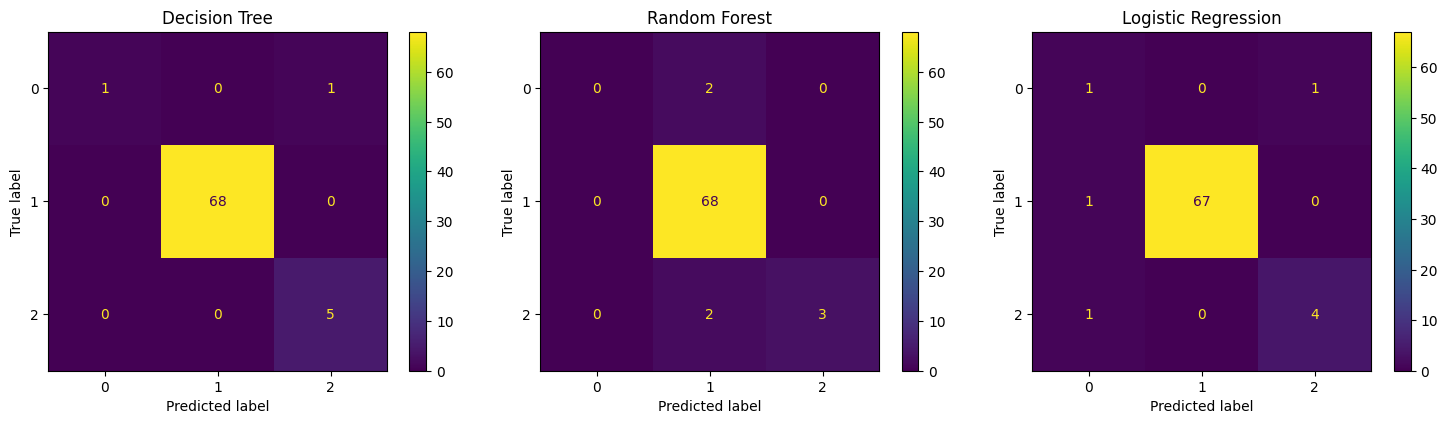

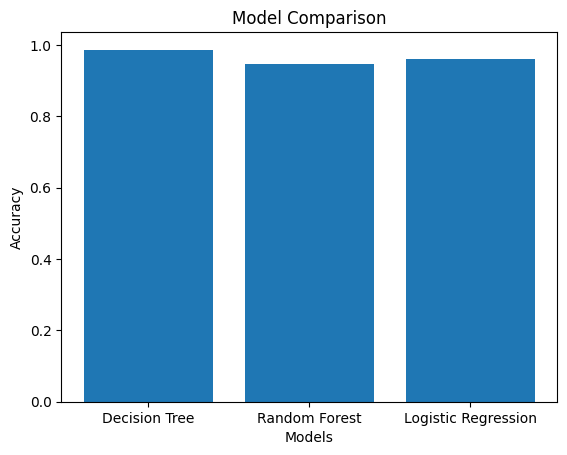

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer # For handling NaNs in X

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Load dataset
data = pd.read_csv('ground_water_quality_2024_post.csv')

# Drop 'sno' if it exists and is an identifier
if 'sno' in data.columns:
    data = data.drop('sno', axis=1)

# Assuming 'Classification.1' is the target column for classification based on available data
target_column = 'Classification.1'
X = data.drop(target_column, axis=1)
y = data[target_column]

# Identify categorical columns for one-hot encoding in X
categorical_cols_X = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns in X
X = pd.get_dummies(X, columns=categorical_cols_X, drop_first=True)

# Handle potential NaN values in X after one-hot encoding, using mean imputation
numerical_cols = X.select_dtypes(include=np.number).columns
imputer_numerical = SimpleImputer(strategy='mean')
X[numerical_cols] = imputer_numerical.fit_transform(X[numerical_cols])

# Convert target variable y to numerical if it's not already (e.g., using LabelEncoder)
if y.dtype == 'object' or y.dtype == 'bool':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
lr = LogisticRegression(max_iter=5000, random_state=42)

# Train models
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# -----------------------------
# Confusion Matrices
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt)).plot(ax=axes[0])
axes[0].set_title("Decision Tree")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(ax=axes[1])
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot(ax=axes[2])
axes[2].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

# -----------------------------
# Accuracy Comparison Graph
# -----------------------------
models = ["Decision Tree", "Random Forest", "Logistic Regression"]
accuracies = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_lr)
]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

Categorical columns identified for encoding: ['district', 'mandal', 'village', 'season', 'Classification', 'Classification.1']

--- Regression Model Evaluation ---

Decision Tree Regressor:
  Mean Squared Error: 0.06829066666666662
  R2 Score: 0.6154444500505755

Random Forest Regressor:
  Mean Squared Error: 0.062004793333333114
  R2 Score: 0.6508411974335144

Linear Regression:
  Mean Squared Error: 0.08716876211162038
  R2 Score: 0.5091389074313021


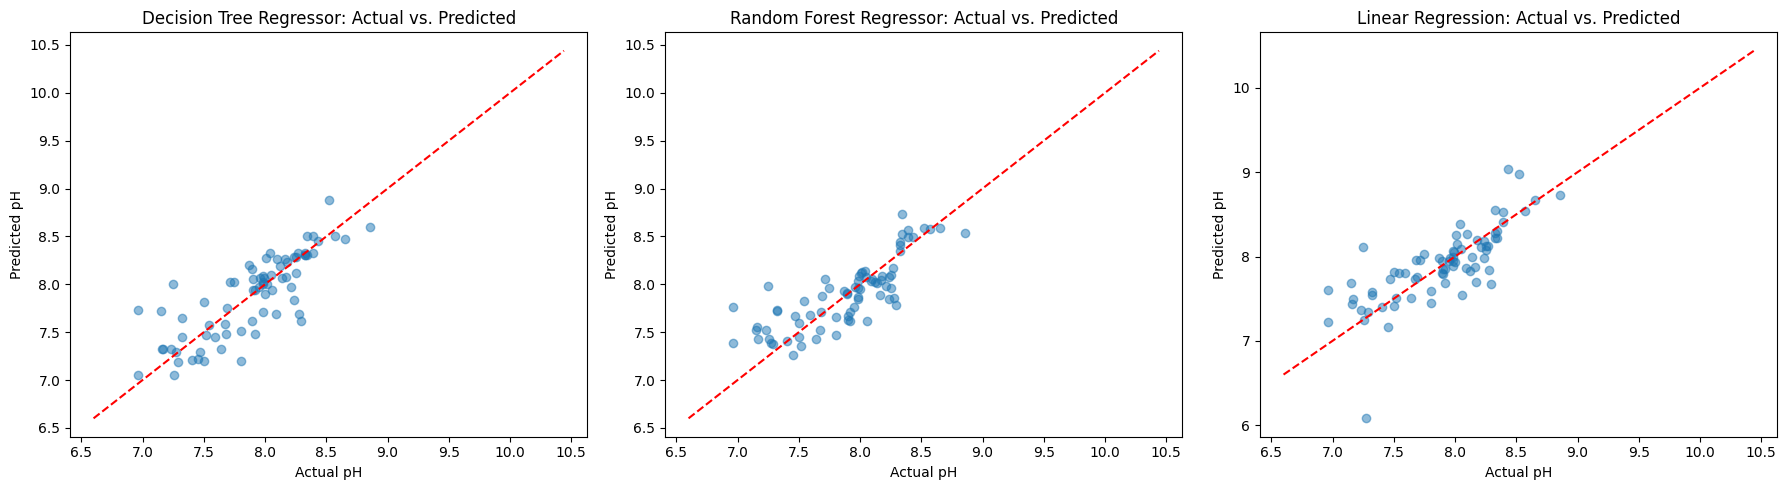

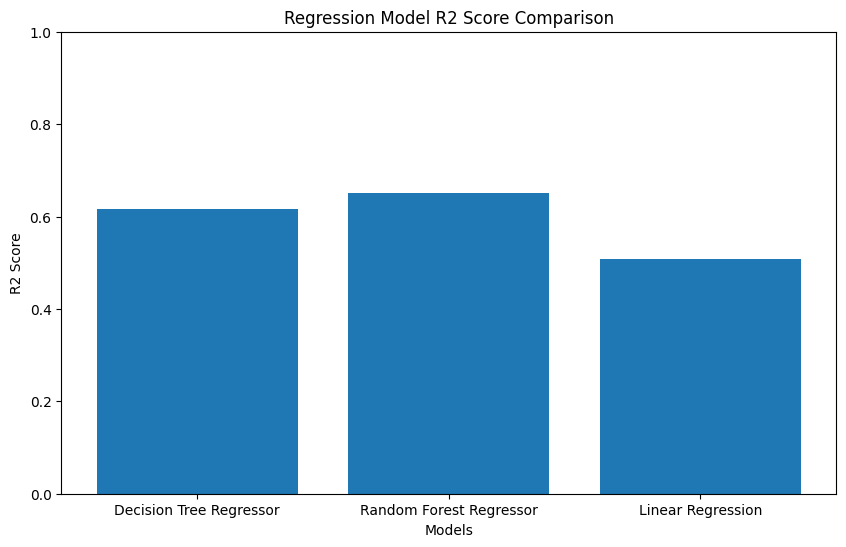

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# from sklearn.datasets import load_ground_water_quality_2024_post # This line caused the error
from sklearn.model_selection import train_test_split
# Import regression metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer # For handling NaNs

# Import regressor models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression # Using LinearRegression as a linear model for regression

# Load dataset - Corrected to load from CSV
data = pd.read_csv('ground_water_quality_2024_post.csv')

# Drop 'sno' as it's likely just an identifier and not a feature
data = data.drop('sno', axis=1)

# Separate features (X) and target (y)
X = data.drop('pH', axis=1)
y = data['pH']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Categorical columns identified for encoding: {list(categorical_cols)}")

# Apply one-hot encoding to categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True) # drop_first to avoid multicollinearity

# Handle potential NaN values in X after one-hot encoding, using mean imputation
numerical_cols = X.select_dtypes(include=np.number).columns
imputer_numerical = SimpleImputer(strategy='mean')
X[numerical_cols] = imputer_numerical.fit_transform(X[numerical_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Added random_state for reproducibility

# Models - Changed to Regression Models
dt_reg = DecisionTreeRegressor(random_state=42)
rf_reg = RandomForestRegressor(random_state=42)
lr_reg = LinearRegression()

# Train models
dt_reg.fit(X_train, y_train)
rf_reg.fit(X_train, y_train)
lr_reg.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_reg.predict(X_test)
y_pred_rf = rf_reg.predict(X_test)
y_pred_lr = lr_reg.predict(X_test)

# Evaluate models using regression metrics
print("\n--- Regression Model Evaluation ---")

# Decision Tree Regressor
print("\nDecision Tree Regressor:")
print("  Mean Squared Error:", mean_squared_error(y_test, y_pred_dt))
print("  R2 Score:", r2_score(y_test, y_pred_dt))

# Random Forest Regressor
print("\nRandom Forest Regressor:")
print("  Mean Squared Error:", mean_squared_error(y_test, y_pred_rf))
print("  R2 Score:", r2_score(y_test, y_pred_rf))

# Linear Regression
print("\nLinear Regression:")
print("  Mean Squared Error:", mean_squared_error(y_test, y_pred_lr))
print("  R2 Score:", r2_score(y_test, y_pred_lr))

# -----------------------------
# Regression Comparison Graph (Predicted vs Actual)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Decision Tree Regressor
axes[0].scatter(y_test, y_pred_dt, alpha=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Reference line
axes[0].set_xlabel("Actual pH")
axes[0].set_ylabel("Predicted pH")
axes[0].set_title("Decision Tree Regressor: Actual vs. Predicted")

# Random Forest Regressor
axes[1].scatter(y_test, y_pred_rf, alpha=0.5)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Reference line
axes[1].set_xlabel("Actual pH")
axes[1].set_ylabel("Predicted pH")
axes[1].set_title("Random Forest Regressor: Actual vs. Predicted")

# Linear Regression
axes[2].scatter(y_test, y_pred_lr, alpha=0.5)
axes[2].plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Reference line
axes[2].set_xlabel("Actual pH")
axes[2].set_ylabel("Predicted pH")
axes[2].set_title("Linear Regression: Actual vs. Predicted")

plt.tight_layout()
plt.show()

# You can also compare R2 scores in a bar chart
models = ["Decision Tree Regressor", "Random Forest Regressor", "Linear Regression"]
r2_scores = [
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_lr)
]

plt.figure(figsize=(10, 6))
plt.bar(models, r2_scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Regression Model R2 Score Comparison")
plt.ylim(0, 1) # R2 scores are typically between 0 and 1, but can be negative
plt.show()

In [ ]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# ================================
# 2. Load Dataset
# ================================
df = pd.read_csv("/ground_water_quality_2024_post.csv")

print(df.head())
print(df.info())

# ================================
# 3. Data Preprocessing
# ================================
# Drop missing values
df = df.dropna()

# Convert categorical to numeric
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col])

# ================================
# 4. Data Visualization
# ================================

# Correlation Heatmap
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(),
    annot=False,      # removes numbers
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()


# Histogram
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

# Pairplot
sns.pairplot(df)
plt.show()

# ================================
# 5. Define Features & Target
# ================================
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # last column as target

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 6. Logistic Regression
# ================================
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# ================================
# 7. Decision Tree
# ================================
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# ================================
# 8. Random Forest
# ================================
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# ================================
# 9. Confusion Matrix Function
# ================================
def plot_conf_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Plot confusion matrices
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")
plot_conf_matrix(y_test, y_pred_dt, "Decision Tree Confusion Matrix")
plot_conf_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")

# ================================
# 10. Classification Report
# ================================
print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- Decision Tree Report ---")
print(classification_report(y_test, y_pred_dt))

print("\n--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))

Output hidden; open in https://colab.research.google.com to view.